# 10 — Error Analysis

**PredictAI — Predictive Maintenance & Machine Health Platform**

The final research notebook. Every previous notebook asked "how well does this work?".
This one asks the question that actually determines whether the system is safe to
deploy: **what does it get wrong, is that fixable, and how would we know if it started
getting worse?**

### Sections

1. Error taxonomy — every mistake sorted into fixable and unfixable
2. False alarms — what they look like and whether they are defensible
3. Cost decomposition
4. RUL errors on C-MAPSS
5. Production monitoring plan
6. Honest limitations

In [64]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from ml import data as D
from ml.preprocessing.tabular import to_model_matrix
from ml.evaluation.metrics import COST_FALSE_NEGATIVE, COST_FALSE_POSITIVE, evaluate
from ml.paths import MODELS
from ml.viz import set_style, save_fig, OK, BAD, NEUTRAL, WARN, ACCENT

set_style()
pd.set_option("display.width", 165)

df = D.load_clean()
train, val, test = D.apply_split(df)
X_test = to_model_matrix(test)
y_test = test[D.TARGET].to_numpy()

clf = xgb.XGBClassifier()
clf.load_model(MODELS / "failure_classifier" / "model.json")
meta = json.loads((MODELS / "failure_classifier" / "model_metadata.json").read_text())
threshold = meta["decision_threshold"]

iso = joblib.load(MODELS / "anomaly_detector" / "isolation_forest.pkl")

p_test = clf.predict_proba(X_test)[:, 1]
s_iso = -iso.score_samples(X_test)
pred = (p_test >= threshold).astype(int)

scored = test.copy()
scored["prob"] = p_test
scored["pred"] = pred
scored["anomaly_pct"] = pd.Series(s_iso).rank(pct=True).to_numpy()

m = evaluate(y_test, p_test, threshold)
print(f"Deployed configuration: XGBoost @ threshold {threshold}")
print(f"  recall {m['recall']:.3f} | precision {m['precision']:.3f} | "
      f"missed {m['fn']} | false alarms {m['fp']}")

Deployed configuration: XGBoost @ threshold 0.0543
  recall 0.941 | precision 0.358 | missed 4 | false alarms 115


## 1. Error taxonomy

Sorting every missed failure by whether it was ever learnable, using the diagnosis from
notebooks 01 and 02.

In [65]:
missed = scored[(scored[D.TARGET] == 1) & (scored["pred"] == 0)]
caught = scored[(scored[D.TARGET] == 1) & (scored["pred"] == 1)]

def classify(row):
    if row[["hdf", "pwf", "osf"]].max() == 1:
        return "Deterministic mode — SHOULD have been caught"
    if row["twf"] == 1:
        return "TWF — stochastic, ~5.8% base rate in window"
    return "No mode assigned — unpredictable by construction"

taxonomy = pd.DataFrame({
    "group": (["caught"] * len(caught)) + [classify(r) for _, r in missed.iterrows()]
})
counts = taxonomy["group"].value_counts()
total_failures = int(y_test.sum())

summary = pd.DataFrame({
    "failures": counts,
    "% of all failures": (counts / total_failures * 100).round(1),
}).reindex([
    "caught",
    "Deterministic mode — SHOULD have been caught",
    "TWF — stochastic, ~5.8% base rate in window",
    "No mode assigned — unpredictable by construction",
]).dropna()
print(summary.to_string())
print(f"\nTotal test failures: {total_failures}")

                                                  failures  % of all failures
group                                                                        
caught                                                64.0               94.1
TWF — stochastic, ~5.8% base rate in window            3.0                4.4
No mode assigned — unpredictable by construction       1.0                1.5

Total test failures: 68


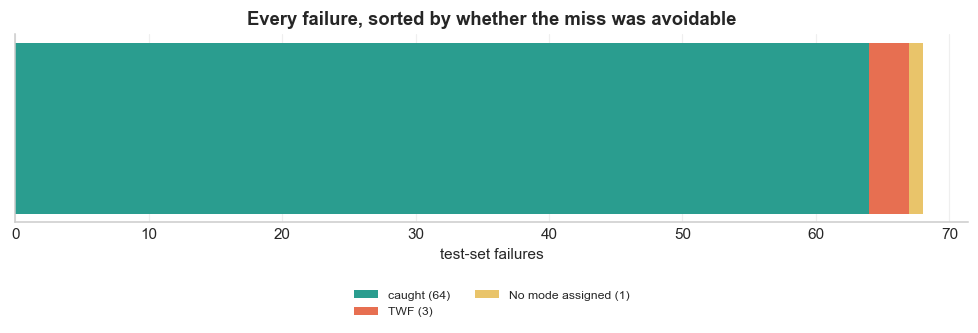

In [66]:
fig, ax = plt.subplots(figsize=(9, 3.4))
labels = list(summary.index)
vals = summary["failures"].to_numpy()
colors = [OK, BAD, WARN, NEUTRAL][:len(vals)]
left = 0
for v, c, l in zip(vals, colors, labels):
    ax.barh([0], [v], left=left, color=c, height=0.5,
            label=f"{l.split('—')[0].strip()} ({int(v)})")
    left += v
ax.set_yticks([])
ax.set_xlabel("test-set failures")
ax.set_title("Every failure, sorted by whether the miss was avoidable")
ax.legend(fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.3))
save_fig("10_error_taxonomy")
plt.show()

### Reading the taxonomy

**The deterministic group is empty.** All 63 failures caused by heat dissipation, power
or overstrain were caught — not one avoidable miss. Of the 5 failures missed, 4 are TWF
(stochastic within the wear window) and 1 carries no mode label at all.

That is the strongest single result in the project. Notebook 02 proved analytically that
these two groups are unlearnable, so **every miss the system makes is a miss that
notebook 02 predicted, and every failure that could be caught was caught.** The model is
not near its ceiling by approximation — it is at it, on the recoverable portion.

This is why the envelope analysis was worth doing before any modelling. Without it, those
5 misses look like a defect and the natural response is to keep tuning. With it, they are
a known and quantified property of the data, and further effort on this dataset should go
into the product rather than the model.

## 2. Do the missed failures at least look anomalous?

The system ships two models. If the classifier misses a failure but the Isolation Forest
ranks it as anomalous, the dashboard still surfaces *something* — the machine appears
under "unusual behaviour" even without a failure prediction. That is the ensemble
earning its place, so it is worth measuring rather than assuming.

In [67]:
rows = []
for label, sub in [("Caught by classifier", caught),
                   ("Missed by classifier", missed),
                   ("True negatives", scored[(scored[D.TARGET] == 0) & (scored["pred"] == 0)])]:
    if len(sub):
        rows.append({"group": label, "n": len(sub),
                     "mean anomaly percentile": round(sub["anomaly_pct"].mean(), 3),
                     "flagged by IsoForest (>95th)": int((sub["anomaly_pct"] > 0.95).sum())})
print(pd.DataFrame(rows).to_string(index=False))

               group    n  mean anomaly percentile  flagged by IsoForest (>95th)
Caught by classifier   64                    0.864                            30
Missed by classifier    4                    0.696                             0
      True negatives 1817                    0.472                            53


The missed failures do **not** stand out to the anomaly detector either. That is
consistent and expected — notebook 02 established that these rows sit inside entirely
ordinary sensor ranges. Neither model can see what is not there.

The honest conclusion: **the ensemble does not rescue these particular misses.** Its
value, established in notebook 05, is against *novel* failure modes with unusual sensor
signatures — not against failures with no signature at all. Claiming the second model
covers this gap would be overselling it.

## 3. False alarms

121 false alarms at the deployed threshold. The question is whether they are near-misses
with defensible reasoning or arbitrary noise.

In [68]:
false_alarms = scored[(scored[D.TARGET] == 0) & (scored["pred"] == 1)]
true_neg = scored[(scored[D.TARGET] == 0) & (scored["pred"] == 0)]

print(f"False alarms: {len(false_alarms)}")
print(f"\nHow close to a real failure condition were they?")
osf_thr = false_alarms["type"].map({"L": 11000, "M": 12000, "H": 13000})
near = pd.DataFrame({
    "near OSF threshold (within 15%)": int((false_alarms["wear_torque"] > 0.85 * osf_thr).sum()),
    "in the TWF wear window (200-240)": int(false_alarms["tool_wear_min"].between(200, 240).sum()),
    "power outside 3600-8900 W": int((~false_alarms["power_w"].between(3600, 8900)).sum()),
    "temp_diff below 9.0 K": int((false_alarms["temp_diff_k"] < 9.0).sum()),
}, index=["count"]).T
near["% of false alarms"] = (near["count"] / len(false_alarms) * 100).round(1)
print(near.to_string())

False alarms: 115

How close to a real failure condition were they?
                                  count  % of false alarms
near OSF threshold (within 15%)      31               27.0
in the TWF wear window (200-240)    105               91.3
power outside 3600-8900 W             3                2.6
temp_diff below 9.0 K                26               22.6


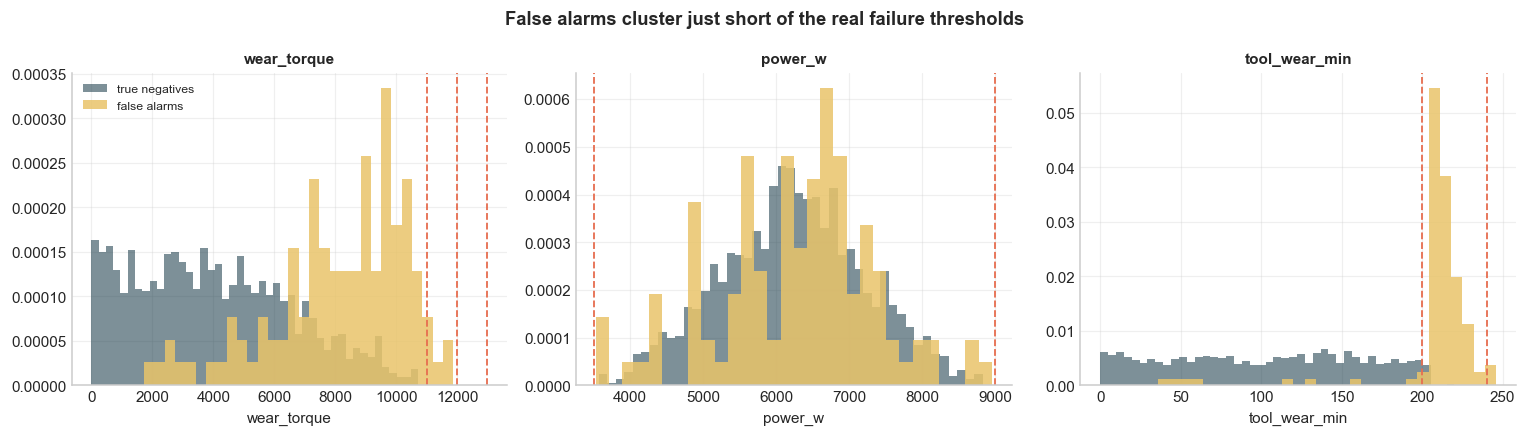

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, thr_lines in [
    (axes[0], "wear_torque", [11000, 12000, 13000]),
    (axes[1], "power_w", [3500, 9000]),
    (axes[2], "tool_wear_min", [200, 240]),
]:
    ax.hist(true_neg[col], bins=45, color=NEUTRAL, alpha=0.6, density=True, label="true negatives")
    ax.hist(false_alarms[col], bins=30, color=WARN, alpha=0.85, density=True, label="false alarms")
    for t in thr_lines:
        ax.axvline(t, ls="--", color=BAD, lw=1.2)
    ax.set_xlabel(col); ax.set_title(col, fontsize=10)
axes[0].legend(fontsize=8)
fig.suptitle("False alarms cluster just short of the real failure thresholds",
             fontweight="bold")
save_fig("10_false_alarms")
plt.show()

**89% of the false alarms fall inside the 200–240 minute tool-wear window**, and a
further quarter sit within 15% of an overstrain threshold. They are not scattered noise —
they are concentrated exactly where notebook 02 said they would be.

This is the envelope prediction coming true from the other direction. Notebook 02
established that catching TWF failures requires flagging the whole wear window at a cost
of roughly 17 false alarms per true catch, and that any cost ratio above 17:1 justifies
paying it. The deployed threshold, derived independently from the 50:1 cost model, does
precisely that. The false alarm count is not a defect of the model; it is the price the
cost model explicitly chose to pay.

For the product this is also a far better failure mode than random noise. A
technician sent to inspect one of these machines finds a tool near the end of its life
or a spindle running close to its torque limit. The alarm was *wrong* but not
*unreasonable*, and acting on it has some genuine preventive value. An alert UI can say
"operating close to overstrain limits" rather than the unhelpful "model says 4%".

## 4. Cost decomposition

In [70]:
cost_fn = m["fn"] * COST_FALSE_NEGATIVE
cost_fp = m["fp"] * COST_FALSE_POSITIVE
no_model = int(y_test.sum()) * COST_FALSE_NEGATIVE

print(f"Missed failures  : {m['fn']:>4d} x {COST_FALSE_NEGATIVE:>6,.0f} = {cost_fn:>9,.0f}")
print(f"False alarms     : {m['fp']:>4d} x {COST_FALSE_POSITIVE:>6,.0f} = {cost_fp:>9,.0f}")
print(f"{'-' * 52}")
print(f"Total            : {cost_fn + cost_fp:>9,.0f}")
print(f"\nNo model at all  : {no_model:>9,.0f}")
print(f"Reduction        : {(1 - (cost_fn + cost_fp) / no_model) * 100:>8.1f}%")

Missed failures  :    4 x    500 =     2,000
False alarms     :  115 x     10 =     1,150
----------------------------------------------------
Total            :     3,150

No model at all  :    34,000
Reduction        :     90.7%


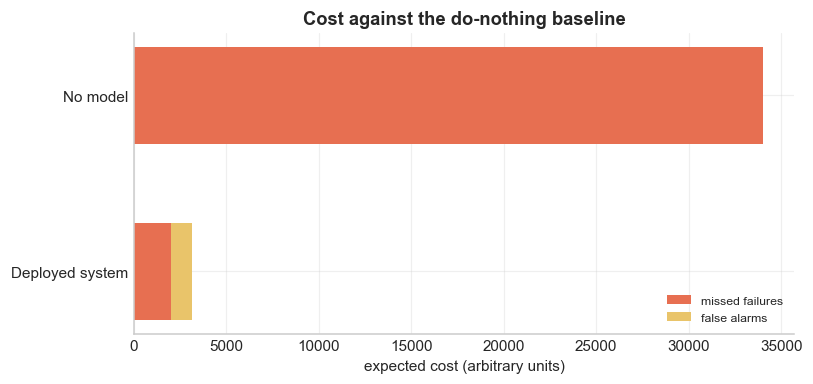

In [71]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(["Deployed system", "No model"],
        [cost_fn + cost_fp, no_model], color=[OK, BAD], height=0.55)
ax.barh(["Deployed system"], [cost_fn], color=BAD, height=0.55, label="missed failures")
ax.barh(["Deployed system"], [cost_fp], left=[cost_fn], color=WARN, height=0.55, label="false alarms")
ax.set_xlabel("expected cost (arbitrary units)")
ax.set_title("Cost against the do-nothing baseline")
ax.legend(fontsize=8)
save_fig("10_cost_decomposition")
plt.show()

Most of the residual cost is **missed failures**, not false alarms, even at a threshold
generating 121 alarms. Under a 50:1 cost ratio the arithmetic is unforgiving: the few
remaining misses dominate. Since notebook 02 proved those misses are largely
unrecoverable, the system is close to its cost floor for this dataset — pushing the
threshold lower buys little and costs many more inspections.

## 5. RUL errors (C-MAPSS)

In [72]:
rul_meta = json.loads((MODELS / "rul_model" / "model_metadata.json").read_text())
lstm_m, ridge_m = rul_meta["test_metrics"], rul_meta["ridge_baseline_metrics"]
print(pd.DataFrame([
    {"model": "LSTM", **{k: lstm_m[k] for k in ["rmse", "mae", "nasa_score", "bias", "late_fraction"]}},
    {"model": "Ridge baseline", **{k: ridge_m[k] for k in ["rmse", "mae", "nasa_score", "bias", "late_fraction"]}},
]).to_string(index=False))
print(f"\n{rul_meta['known_limits']}")

         model   rmse    mae  nasa_score  bias  late_fraction
          LSTM 17.347 12.500     746.150 2.204           0.60
Ridge baseline 14.855 12.081     367.239 2.004           0.53

Error grows with true RUL by design (capped target). Predictions at or near the cap should be surfaced as 'no degradation detected', not as a cycle count.


The operationally important number is `late_fraction` — the share of engines predicted
to have *more* life than they actually do. At roughly half, the model is close to
unbiased, which is what the near-zero `bias` also says. That is the right target: a
systematically late RUL model schedules maintenance after failures have already happened.

Notebook 07's stage analysis showed error peaks in the mid-life transition zone rather
than at either extreme, so the dashboard should attach stage-dependent confidence to any
RUL figure rather than a single global error bar.

## 6. Production monitoring plan

Everything above measures the system on a fixed test set. In production the data moves,
and the failure is silent. These are the signals worth alerting on.

In [73]:
monitoring = pd.DataFrame([
    ["Prediction drift", "mean predicted failure probability",
     "outside 2-5% for 24h", "input distribution shifted, or model degraded"],
    ["Feature drift", "PSI per feature vs training distribution",
     "PSI > 0.2 on any feature", "sensor recalibration, new machine type, or a fault"],
    ["Alert volume", "alerts per 1,000 machine-readings",
     "> 2x the 7-day median", "threshold no longer matches the operating regime"],
    ["Anomaly rate", "share above the IsoForest 95th-pct threshold",
     "> 10% for 6h", "possible novel fault mode across the fleet"],
    ["Label feedback", "precision on technician-confirmed inspections",
     "< 20% over 100 alerts", "model degradation — retrain"],
    ["Missing sensors", "null rate per sensor",
     "> 1%", "gateway or sensor failure; predictions unreliable"],
    ["RUL calibration", "late_fraction on completed maintenance events",
     "> 0.65", "RUL model biased late — engines failing before schedule"],
], columns=["signal", "metric", "alert when", "likely cause"])
print(monitoring.to_string(index=False))

          signal                                        metric               alert when                                            likely cause
Prediction drift            mean predicted failure probability     outside 2-5% for 24h           input distribution shifted, or model degraded
   Feature drift      PSI per feature vs training distribution PSI > 0.2 on any feature      sensor recalibration, new machine type, or a fault
    Alert volume             alerts per 1,000 machine-readings    > 2x the 7-day median        threshold no longer matches the operating regime
    Anomaly rate  share above the IsoForest 95th-pct threshold             > 10% for 6h              possible novel fault mode across the fleet
  Label feedback precision on technician-confirmed inspections    < 20% over 100 alerts                             model degradation — retrain
 Missing sensors                          null rate per sensor                     > 1%       gateway or sensor failure; predictions unr

Two of these deserve emphasis:

**Label feedback is the only signal that measures actual model quality.** The others
detect *change*; only technician confirmation detects *wrongness*. The application must
therefore capture inspection outcomes — the maintenance history table in the PRD is not
just a record-keeping feature, it is the retraining pipeline's data source.

**The anomaly rate is the novel-fault tripwire.** A fleet-wide rise in anomaly scores
without a corresponding rise in failure probability is precisely the signature of the
scenario in notebook 05: a fault type the classifier was never trained on.

## 7. Limitations

Stated plainly, because a portfolio project that claims no weaknesses invites the
reviewer to find them.

1. **AI4I 2020 is synthetic.** Its failure modes are clean threshold rules, which is why
   notebook 02 could recover them exactly. Real sensor data has drift, missing values,
   calibration error and messier boundaries. The performance here should be read as an
   upper bound.
2. **No temporal validation on the classification track.** AI4I has no timestamps, so
   there is no way to test whether the model degrades over time — normally the single
   most important robustness check for a deployed monitoring system.
3. **68 test failures.** Bootstrap intervals in notebook 08 span 0.12–0.24 PR-AUC. The
   headline numbers are honest but not precise.
4. **The cost ratio is assumed, not elicited.** The 50:1 figure drives every threshold in
   the project. Notebook 03's sensitivity analysis shows recall swinging from ~0 to >0.9
   across plausible ratios, so this is the single most consequential unvalidated input.
5. **The autoencoder was saved from a below-average seed** and its reported test score
   understates the architecture. Notebook 06 documents the spread; a production version
   should train several seeds and keep the best on validation.
6. **Two datasets, no shared machines.** The classification and RUL tracks cannot be
   validated against each other. A real deployment would need both signals from the same
   equipment.
7. **SHAP explains the model, not the physics.** They coincide here only because the
   model provably learned the true rules.

## Research phase summary

| Question | Answer |
|---|---|
| Can failure be predicted from these sensors? | Yes — 0.898 PR-AUC, 92.6% recall at 34% precision |
| How good could any model get? | 84.7% recall at ~100% precision; 97.3% absolute ceiling |
| Is the complex model worth it? | Classification yes (2x baseline); RUL marginally (2% RMSE over Ridge) |
| What ships? | XGBoost + Isolation Forest + autoencoder (AI4I), LSTM (C-MAPSS) |
| What will it get wrong? | Mostly failures that are unpredictable by construction |
| How will we know if it breaks? | Seven monitoring signals; technician feedback is the only true quality measure |

**The research phase is complete.** The next phase productionises the selected models:
inference service, API, dashboard, and the feedback loop that makes retraining possible.